## SUPPORTLYTICS - Milestone 1: Data Setup & Feature Engineering


### 1. Module 1:- Project Initialization and Dataset setup

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [39]:
# Define Project Objectives and KPIs

print("\nPrimary Goal")
print("- Analyze IT support ticket data to improve resolution time and service efficiency.")

print("\nSecondary Goals")
print("1. Identify performance trends across regions and ticket types.")
print("2. Find common customer requests and technical issues.")
print("3. Group similar issues to improve resource allocation.")
print("4. Suggest workflow improvements based on data analysis.")

print("\nKey Performance Indicators (KPIs)")
print("1. Average Resolution Time")
print("   - Average time taken to resolve a ticket (hours).")

print("2. First Response Time")
print("   - Time taken to respond to a ticket for the first time.")

print("3. SLA Compliance Rate")
print("   - Percentage of tickets resolved within the SLA.")

print("4. Customer Satisfaction")
print("   - Average customer rating (1-5).")

print("5. Ticket Volume")
print("   - Number of tickets by region, priority, and category.")

print("6. Escalation Rate")
print("   - Percentage of tickets that were escalated.")

print("7. Resolution Rate by Priority")
print("   - Number of resolved tickets for each priority level.")

print("8. Top Issue Categories")
print("   - Most frequently reported issue types.")



Primary Goal
- Analyze IT support ticket data to improve resolution time and service efficiency.

Secondary Goals
1. Identify performance trends across regions and ticket types.
2. Find common customer requests and technical issues.
3. Group similar issues to improve resource allocation.
4. Suggest workflow improvements based on data analysis.

Key Performance Indicators (KPIs)
1. Average Resolution Time
   - Average time taken to resolve a ticket (hours).
2. First Response Time
   - Time taken to respond to a ticket for the first time.
3. SLA Compliance Rate
   - Percentage of tickets resolved within the SLA.
4. Customer Satisfaction
   - Average customer rating (1-5).
5. Ticket Volume
   - Number of tickets by region, priority, and category.
6. Escalation Rate
   - Percentage of tickets that were escalated.
7. Resolution Rate by Priority
   - Number of resolved tickets for each priority level.
8. Top Issue Categories
   - Most frequently reported issue types.


In [40]:
# Load Dataset
df = pd.read_csv('archive/customer_support_tickets_200k.csv')

In [41]:
# Dataset Schema And Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  str    
 2   customer_email               200000 non-null  str    
 3   product                      200000 non-null  str    
 4   category                     200000 non-null  str    
 5   issue_description            200000 non-null  str    
 6   resolution_notes             200000 non-null  str    
 7   priority                     200000 non-null  str    
 8   status                       200000 non-null  str    
 9   channel                      200000 non-null  str    
 10  region                       200000 non-null  str    
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  str    
 13  subscripti

In [42]:
# Dataset Overview
print(f"Total Columns: {df.shape[1]}")
print(f"Numeric : {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical : {df.select_dtypes(include=['object', 'str']).shape[1]}")
print(f"DateTime : {df.select_dtypes(include='datetime').shape[1]}")

Total Columns: 30
Numeric : 8
Categorical : 22
DateTime : 0


In [43]:
# Statistical overview of all columns
df.describe()

,ticket_id,customer_age,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,issue_complexity_score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,46.469040,30.377675,9.992115,3.001065,36.309180,120.539718,5.501365
std,57735.171256,16.754304,17.326224,6.053142,1.412273,20.654575,68.969143,2.875587
min,1.000000,18.000000,1.000000,0.000000,1.000000,0.500000,1.000000,1.000000
25%,50000.750000,32.000000,15.000000,5.000000,2.000000,18.460000,60.810000,3.000000
50%,100000.500000,46.000000,30.000000,10.000000,3.000000,36.310000,120.450000,6.000000
75%,150000.250000,61.000000,45.000000,15.000000,4.000000,54.220000,180.260000,8.000000
max,200000.000000,75.000000,60.000000,20.000000,5.000000,72.000000,240.000000,10.000000


In [44]:
# Calculation missing vals and percentage of missing values
missing_vals = df.isnull().sum()
print(f"Missing_values : {missing_vals}")

Missing_values : ticket_id                          0
customer_name                      0
customer_email                     0
product                            0
category                           0
issue_description                  0
resolution_notes                   0
priority                           0
status                             0
channel                            0
region                             0
customer_age                       0
customer_gender                    0
subscription_type                  0
customer_tenure_months             0
previous_tickets                   0
customer_satisfaction_score        0
first_response_time_hours          0
resolution_time_hours              0
ticket_created_date                0
ticket_resolved_date               0
escalated                          0
sla_breached                       0
operating_system                   0
browser                        40023
payment_method                     0
language             

In [45]:
missing_cent = df.isnull().mean()
print(f"Missing_percentage : \n{missing_cent*100}")

Missing_percentage : 
ticket_id                       0.0000
customer_name                   0.0000
customer_email                  0.0000
product                         0.0000
category                        0.0000
issue_description               0.0000
resolution_notes                0.0000
priority                        0.0000
status                          0.0000
channel                         0.0000
region                          0.0000
customer_age                    0.0000
customer_gender                 0.0000
subscription_type               0.0000
customer_tenure_months          0.0000
previous_tickets                0.0000
customer_satisfaction_score     0.0000
first_response_time_hours       0.0000
resolution_time_hours           0.0000
ticket_created_date             0.0000
ticket_resolved_date            0.0000
escalated                       0.0000
sla_breached                    0.0000
operating_system                0.0000
browser                        20.0115
pay

In [46]:
# Calculating initial ticket distribution by Type, Priority, and Category
priority_dist = df['priority'].value_counts().rename_axis('Priority').reset_index(name='Ticket Count')
category_dist = df['category'].value_counts().rename_axis('Category').reset_index(name='Ticket Count')
product_dist = df['product'].value_counts().rename_axis('Product Type').reset_index(name='Ticket Count')

In [47]:
print(f"Ticket Distribution w.r.t Priority : \n\n{priority_dist}")

Ticket Distribution w.r.t Priority : 

  Priority  Ticket Count
0     High         50241
1   Urgent         50143
2   Medium         49854
3      Low         49762


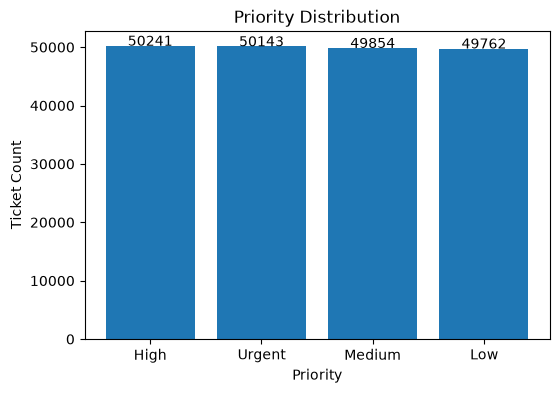

In [48]:
plt.figure(figsize=(6,4))

bars = plt.bar(priority_dist["Priority"], priority_dist["Ticket Count"])

for i in bars:
    plt.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha="center")

plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Ticket Count")

plt.show()

In [49]:
print(f"Ticket Distribution w.r.t Category : \n\n{category_dist}")

Ticket Distribution w.r.t Category : 

                    Category  Ticket Count
0            Feature Request         20169
1  Subscription Cancellation         20096
2          Performance Issue         20074
3           Security Concern         20040
4                Login Issue         20002
5            Payment Problem         19997
6                 Bug Report         19981
7             Refund Request         19900
8            Data Sync Issue         19877
9         Account Suspension         19864


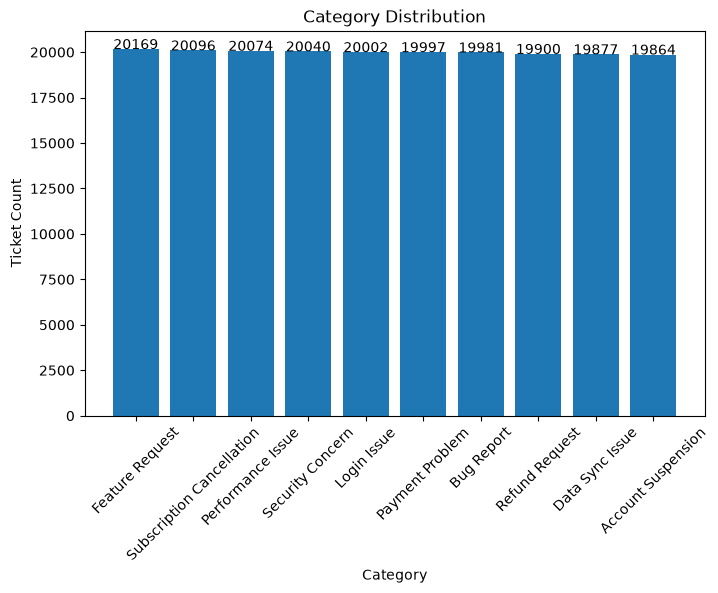

In [50]:
plt.figure(figsize=(8,5))

bars = plt.bar(category_dist["Category"], category_dist["Ticket Count"])

for i in bars:
    plt.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha="center")

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Ticket Count")
plt.xticks(rotation=45)

plt.show()

In [51]:
print(f"Ticket Distribution w.r.t Product : \n\n{product_dist}")

Ticket Distribution w.r.t Product : 

           Product Type  Ticket Count
0        Billing System         20111
1          CRM Platform         20097
2      E-commerce Store         20095
3         Cloud Storage         20056
4            Mobile App         20043
5   Analytics Dashboard         19974
6            Web Portal         19954
7       Payment Gateway         19952
8  Subscription Service         19883
9           API Service         19835


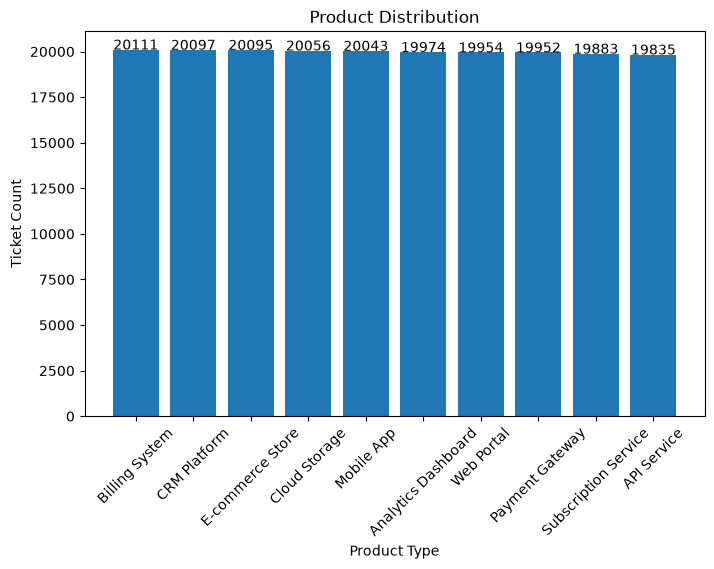

In [52]:
plt.figure(figsize=(8,5))

bars = plt.bar(product_dist["Product Type"], product_dist["Ticket Count"])

for i in bars:
    plt.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha="center")

plt.title("Product Distribution")
plt.xlabel("Product Type")
plt.ylabel("Ticket Count")
plt.xticks(rotation=45)

plt.show()

### 2. Module 2:- Data Cleaning and Feature Engineering

In [53]:
# Handling Missing Values & Cleaning Text

df['browser'] = df['browser'].fillna('Other/Not Applicable')

text_cols = df.select_dtypes(include=['object', 'str']).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

print(f"Total missing values remaining : {df.isnull().sum().sum()}")
print(f"\nBrowser column distribution after cleanup :\n{df['browser'].value_counts().head()}")

Total missing values remaining : 0

Browser column distribution after cleanup :
browser
Safari                  40156
Other/Not Applicable    40023
Firefox                 39983
Chrome                  39972
Edge                    39866
Name: count, dtype: int64


In [54]:
# converting date columns to proper datetime format
df['ticket_created_date'] = pd.to_datetime(df['ticket_created_date'], errors='coerce')
df['ticket_resolved_date'] = pd.to_datetime(df['ticket_resolved_date'], errors='coerce')

In [55]:
# extracting Resolution_Duration in hours
df['Resolution_Duration'] = (df['ticket_resolved_date'] - df['ticket_created_date']).dt.total_seconds() / 3600
df['Resolution_Duration'] = df['Resolution_Duration'].round(2)

In [56]:
# encoding priority into numerical scores for correlation and clustering later
priority_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Urgent': 4}
df['Priority_Score'] = df['priority'].map(priority_map)

In [58]:
# newly added columns
df[['priority', 'Priority_Score', 'ticket_created_date', 'ticket_resolved_date', 'Resolution_Duration']].head()

,priority,Priority_Score,ticket_created_date,ticket_resolved_date,Resolution_Duration
0,Urgent,4,2023-05-17,2023-05-20,72.0
1,Urgent,4,2024-01-06,2024-01-19,312.0
2,Medium,2,2022-11-30,2022-12-05,120.0
3,Medium,2,2024-03-21,2024-04-04,336.0
4,High,3,2024-08-16,2024-08-24,192.0


In [64]:
# saving the processed dataset 
clean_filename = 'processed_customer_support_tickets.csv'
df.to_csv(clean_filename, index=False)
print(f"\nCleaned dataset saved successfully as '{clean_filename}'")


Cleaned dataset saved successfully as 'processed_customer_support_tickets.csv'


In [61]:
df = pd.read_csv('processed_customer_support_tickets.csv')